<a href="https://colab.research.google.com/github/manasagolla25-byte/manasa-M-Tech-Project/blob/main/Comparision_of_ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("/content/diabetes_integers_dataset.csv")
df.head()

,Age,Gender,BMI,Temperature,HeartRate,Glucose,BP_Systolic,BP_Diastolic,Diabetes_Type
0,23,Male,18,99,84,196,102,85,Type 1
1,77,Female,30,98,81,94,124,76,No Diabetes
2,39,Female,29,98,104,155,133,81,Gestational
3,25,Female,30,98,100,188,121,90,Gestational
4,45,Female,37,98,100,182,149,70,Type 2


In [ ]:
# Encode Gender
gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"])

# Encode Target
target_encoder = LabelEncoder()
df["Diabetes_Type"] = target_encoder.fit_transform(df["Diabetes_Type"])

# Split features & target
X = df.drop("Diabetes_Type", axis=1)
y = df["Diabetes_Type"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (important for SVM, KNN, LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(max_depth=10),

    "Random Forest": RandomForestClassifier(n_estimators=300),

    "SVM": SVC(kernel='rbf'),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )
}

In [ ]:
results = []

for name, model in models.items():

    print(f"\n🔹 Training {name}...")

    # Use scaled data for some models
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append((name, acc))

    print(f"✅ Accuracy: {acc:.4f}")


🔹 Training Logistic Regression...
✅ Accuracy: 0.9413

🔹 Training KNN...
✅ Accuracy: 0.9362

🔹 Training Decision Tree...
✅ Accuracy: 0.9585

🔹 Training Random Forest...
✅ Accuracy: 0.9647

🔹 Training SVM...
✅ Accuracy: 0.9503

🔹 Training XGBoost...
✅ Accuracy: 0.9640


In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n🏆 Model Comparison:")
print(results_df)


🏆 Model Comparison:
                 Model  Accuracy
3        Random Forest  0.964667
5              XGBoost  0.964000
2        Decision Tree  0.958500
4                  SVM  0.950333
0  Logistic Regression  0.941333
1                  KNN  0.936167


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("\n🔥 Best Model:", best_model_name)

best_model = models[best_model_name]

# Predict again
if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n📉 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


🔥 Best Model: Random Forest

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1475
           1       1.00      1.00      1.00      1568
           2       0.97      0.97      0.97      1466
           3       0.98      0.94      0.96      1491

    accuracy                           0.96      6000
   macro avg       0.96      0.96      0.96      6000
weighted avg       0.97      0.96      0.96      6000


📉 Confusion Matrix:
[[1399    0   49   27]
 [   0 1568    0    0]
 [  44    0 1422    0]
 [  92    0    0 1399]]


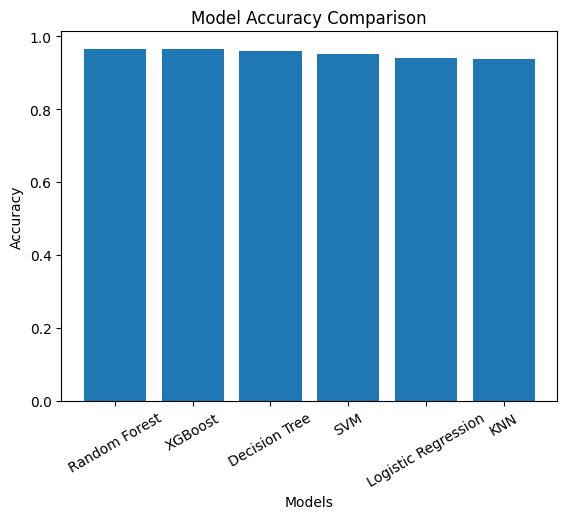

In [ ]:
import matplotlib.pyplot as plt

# Bar Chart
plt.figure()

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

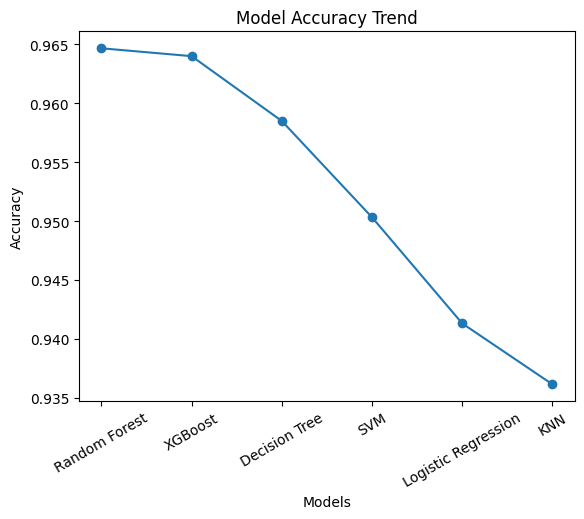

In [ ]:
plt.figure()

plt.plot(results_df["Model"], results_df["Accuracy"], marker='o')

plt.title("Model Accuracy Trend")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

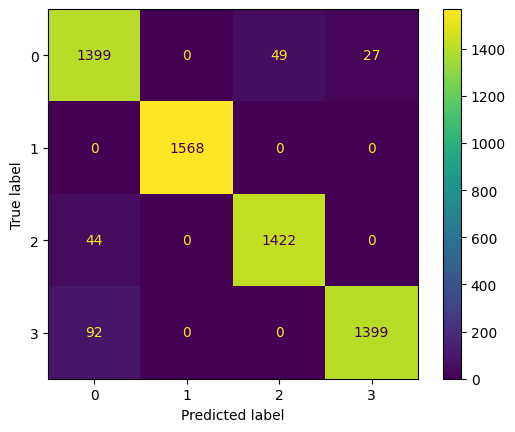

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: Random Forest
Best Accuracy: 0.9646666666666667


In [ ]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# The 'Gender' column does not exist in the new dataset '/content/diabetes.csv'.
# Remove or comment out the line for Gender encoding.
# gender_encoder = LabelEncoder()
# df["Gender"] = gender_encoder.fit_transform(df["Gender"])

# Encode Target - The target column in this dataset is 'Outcome' not 'Diabetes_Type'
target_encoder = LabelEncoder()
df["Outcome"] = target_encoder.fit_transform(df["Outcome"])

# Split features & target
X = df.drop("Outcome", axis=1) # Drop 'Outcome' as it's the target
y = df["Outcome"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (important for SVM, KNN, LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(max_depth=10),

    "Random Forest": RandomForestClassifier(n_estimators=300),

    "SVM": SVC(kernel='rbf'),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )
}

In [ ]:
results = []

for name, model in models.items():

    print(f"\n🔹 Training {name}...")

    # Use scaled data for some models
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append((name, acc))

    print(f"✅ Accuracy: {acc:.4f}")


🔹 Training Logistic Regression...
✅ Accuracy: 0.7532

🔹 Training KNN...
✅ Accuracy: 0.6948

🔹 Training Decision Tree...
✅ Accuracy: 0.7532

🔹 Training Random Forest...
✅ Accuracy: 0.7468

🔹 Training SVM...
✅ Accuracy: 0.7338

🔹 Training XGBoost...
✅ Accuracy: 0.7338


In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n🏆 Model Comparison:")
print(results_df)


🏆 Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.753247
2        Decision Tree  0.753247
3        Random Forest  0.740260
4                  SVM  0.733766
5              XGBoost  0.733766
1                  KNN  0.694805


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("\n🔥 Best Model:", best_model_name)

best_model = models[best_model_name]

# Predict again
if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n📉 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


🔥 Best Model: Random Forest

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
           1       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


📉 Confusion Matrix:
[[79 20]
 [19 36]]


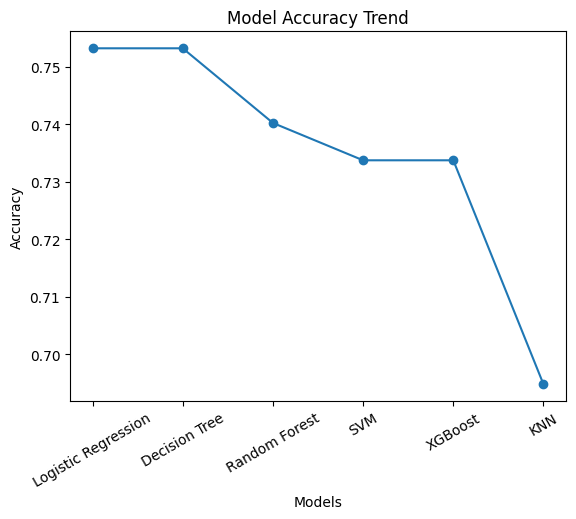

In [ ]:
plt.figure()

plt.plot(results_df["Model"], results_df["Accuracy"], marker='o')

plt.title("Model Accuracy Trend")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

In [ ]:
best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: Logistic Regression
Best Accuracy: 0.7532467532467533


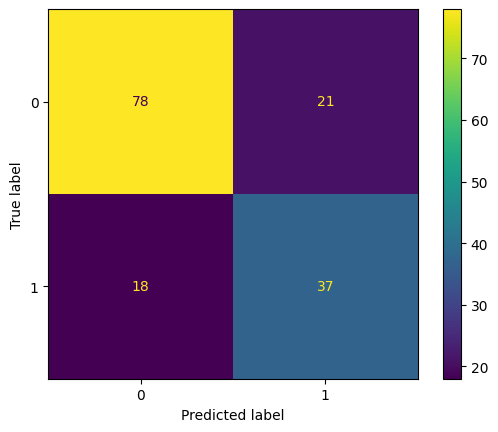

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
df = pd.read_csv("/content/diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# The 'Gender' column does not exist in the new dataset '/content/diabetes.csv'.
# Remove or comment out the line for Gender encoding.
# gender_encoder = LabelEncoder()
# df["Gender"] = gender_encoder.fit_transform(df["Gender"])

# Encode Target - The target column in this dataset is 'Outcome' not 'Diabetes_Type'
target_encoder = LabelEncoder()
df["Outcome"] = target_encoder.fit_transform(df["Outcome"])

# Split features & target
X = df.drop("Outcome", axis=1) # Drop 'Outcome' as it's the target
y = df["Outcome"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (important for SVM, KNN, LR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(max_depth=10),

    "Random Forest": RandomForestClassifier(n_estimators=300),

    "SVM": SVC(kernel='rbf'),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )
}

In [ ]:
results = []

for name, model in models.items():

    print(f"\n🔹 Training {name}...")

    # Use scaled data for some models
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append((name, acc))

    print(f"✅ Accuracy: {acc:.4f}")


🔹 Training Logistic Regression...
✅ Accuracy: 0.7532

🔹 Training KNN...
✅ Accuracy: 0.6948

🔹 Training Decision Tree...
✅ Accuracy: 0.7532

🔹 Training Random Forest...
✅ Accuracy: 0.7403

🔹 Training SVM...
✅ Accuracy: 0.7338

🔹 Training XGBoost...
✅ Accuracy: 0.7338


In [ ]:
from sklearn.model_selection import train_test_split

# 20% test → 6,000 samples
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples:", len(X_train))   # 18,000
print("Testing Samples :", len(X_test))    # 12,000

Training Samples: 24000
Testing Samples : 6000


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(max_depth=10),

    "Random Forest": RandomForestClassifier(n_estimators=300),

    "SVM": SVC(kernel='rbf'),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )
}

In [ ]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():

    print(f"\n🔹 Training {name}...")

    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    print(f"✅ Accuracy: {acc:.4f}")


🔹 Training Logistic Regression...
✅ Accuracy: 0.9413

🔹 Training KNN...
✅ Accuracy: 0.9362

🔹 Training Decision Tree...
✅ Accuracy: 0.9585

🔹 Training Random Forest...
✅ Accuracy: 0.9638

🔹 Training SVM...
✅ Accuracy: 0.9503

🔹 Training XGBoost...
✅ Accuracy: 0.9640


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\n🏆 Model Comparison:")
print(results_df)


🏆 Model Comparison:
                 Model  Accuracy
5              XGBoost  0.964000
3        Random Forest  0.963833
2        Decision Tree  0.958500
4                  SVM  0.950333
0  Logistic Regression  0.941333
1                  KNN  0.936167


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

best_model_name = results_df.iloc[0]["Model"]
print("\n🔥 Best Model:", best_model_name)

best_model = models[best_model_name]

if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n📉 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


🔥 Best Model: XGBoost

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1475
           1       1.00      1.00      1.00      1568
           2       0.96      0.97      0.96      1466
           3       0.98      0.95      0.96      1491

    accuracy                           0.96      6000
   macro avg       0.96      0.96      0.96      6000
weighted avg       0.96      0.96      0.96      6000


📉 Confusion Matrix:
[[1389    0   54   32]
 [   0 1568    0    0]
 [  49    0 1417    0]
 [  81    0    0 1410]]
